In [43]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# load dataset
x=pd.read_csv("customer_data.csv")
print("dataset loaded successfully")
print("Shape",x.shape)

dataset loaded successfully
Shape (7043, 21)


In [45]:
x.head() # look at first few rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
x.info() # understand column types

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [47]:
# statistics for numerical values alone
x.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [48]:
# since we know total charge is float(Since money)but here it is given as str so we should fix that column
x["TotalCharges"]=pd.to_numeric(x['TotalCharges'],errors='coerce')
x['TotalCharges'].dtype

dtype('float64')

In [49]:
# check missing values
print("Before", x.shape)
x.isnull().sum()

Before (7043, 21)


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [50]:
# now drop missing values
x.dropna(inplace=True)
print("After:",x.shape)

After: (7032, 21)


In [51]:
#check duplicates
x.duplicated().sum() # since 0 duplicates no need to drop it 'x.drop_duplicates(inplace=True)'

np.int64(0)

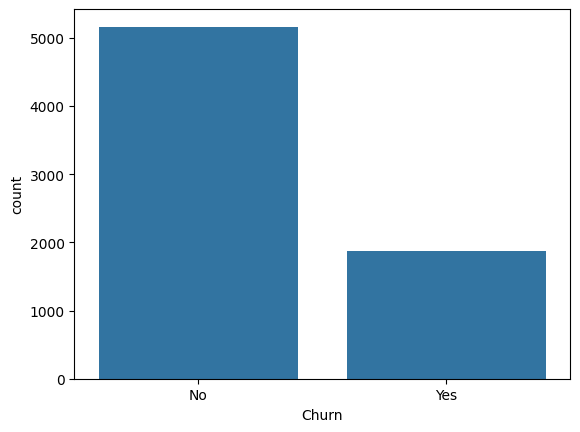

In [52]:
#  for better understanding of dataset => we are going to visualize it using seaborn
sns.countplot(x='Churn',data=x)# count categories
plt.show()

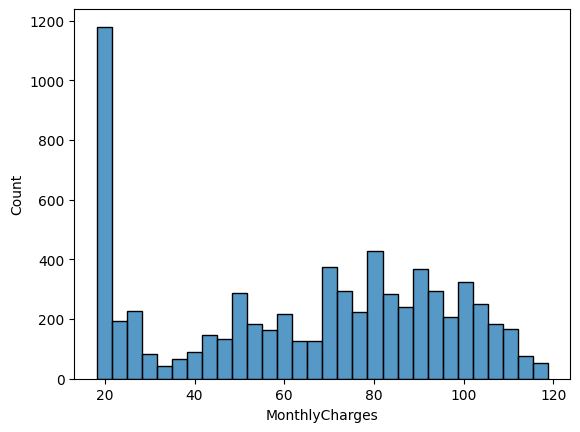

In [53]:
sns.histplot(x['MonthlyCharges'],bins=30) # monthly charges distribution
plt.show()

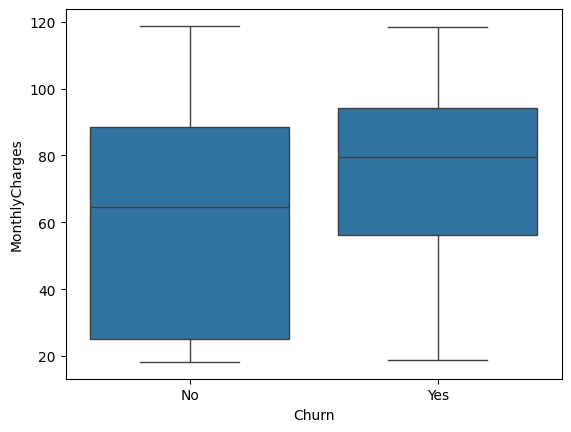

In [54]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=x) # now compare Churn and MonthlyCharges
plt.show()

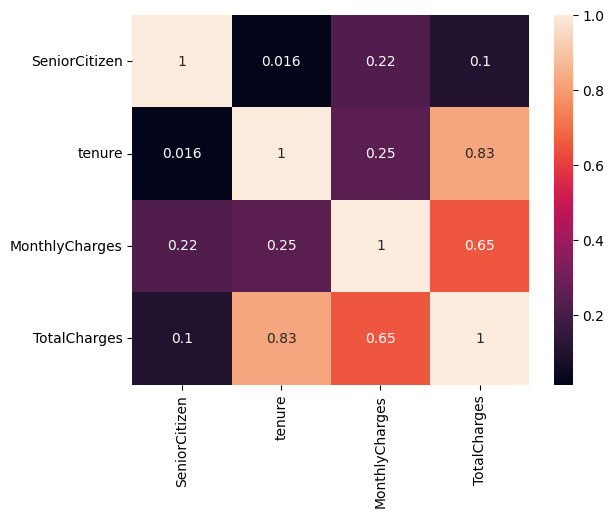

In [55]:
corr=x.corr(numeric_only=True) # shows the relationship between numeric column
sns.heatmap(corr,annot=True)
plt.show()

In [56]:
x.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [57]:
# in above we know that 'customerID' is not used used mostly so will drop the unneccessay columns
x.drop('customerID',axis=1,inplace=True)
x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [58]:
x.nunique() # checks which column has 2 values for label encoding

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [59]:
# sometimes in label encoding takes 3 values if column values are like yes,no, no phone service
for col in x.select_dtypes('str').columns:
    print(col,'->',x[col].nunique(),'->',x[col].unique())

gender -> 2 -> <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner -> 2 -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents -> 2 -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService -> 2 -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines -> 3 -> <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService -> 3 -> <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity -> 3 -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup -> 3 -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection -> 3 -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport -> 3 -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV -> 3 -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies -> 3 -> <StringArray>
['No', 'Yes', 'No internet serv

In [60]:
# label encoding columns :
#gender, Partner, Dependents, PhoneService,PaperlessBilling, Churn, MultipleLines,
#OnlineSecurity, OnlineBackup, DeviceProtection,TechSupport, StreamingTV, StreamingMovies

# one hot encoding:Contract, InternetService, PaymentMethod

In [61]:
# label encoding-converting yes/no to 1/0
labels=['gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling',
        'Churn']

for col in labels:
    x[col]=x[col].map({'Yes':1,'No':0,'Male':1,'Female':0,'No phone service':0,'No internet service':0})
# to verify this
print(x['gender'].unique())
print(x['TechSupport'].unique())

[0 1]
[0 1]


In [62]:
#one hot encoding ->used when a column has 3 or more genuine cateories
#working =>creates a binary(0 or 1) column for each catgeory and drops first binary column  because it only give useless extra information
x=pd.get_dummies(x,columns=['Contract', 'InternetService', 'PaymentMethod'],drop_first=True,dtype=int)
# verify
print(x.shape)
print(x.dtypes)
print(x.select_dtypes('object').columns)
# Index([], dtype='str') → [] = empty = no object columns = data is clean 

(7032, 24)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
Contract_One year                          int64
Contract_Two year                          int64
InternetService_Fiber optic                int64
InternetS

In [63]:
#sklearn -'scikit- learn'- an ready made ml tool box
# provides tools for preprocessing,model_selection,linear_model,ensemble,metrics,tree
x.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,...,64.798208,2283.300441,0.265785,0.209329,0.239619,0.440273,0.216155,0.216297,0.336320,0.228100
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,...,30.085974,2266.771362,0.441782,0.406858,0.426881,0.496455,0.411650,0.411748,0.472483,0.419637
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,35.587500,401.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,70.350000,1397.475000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,89.862500,3794.737500,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [64]:
#preprocessing tool uses 'standard scaller' property
#scalling ->bringing numeric columns to same range 
#Standard scaler (formula)->new val=(original val-mean)/standard devivation
# 'x.descibe()' tells us which colums will be scaled

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
cols=['tenure','MonthlyCharges','TotalCharges'] # in above table every column has binary vaues except these 3 so they should be scaled
x[cols]=scaler.fit_transform(x[cols])
print(x[cols].describe().round(2))
# after scalling mean=0 and std=1 

        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     -0.00            0.00         -0.00
std       1.00            1.00          1.00
min      -1.28           -1.55         -1.00
25%      -0.95           -0.97         -0.83
50%      -0.14            0.18         -0.39
75%       0.92            0.83          0.67
max       1.61            1.79          2.82


In [65]:
# train-test split=>80% percent of the dataset is used for training model and remaining 20% is for testing model
from sklearn.model_selection import train_test_split
# separate features and target
X=x.drop('Churn',axis=1) # features
Y=x['Churn']
# uses the main 4 variables
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,# test :20% and train :80%
                                               random_state=42, # it avoids getting diffrent split for training every time we run 
                                               stratify=Y) # maintain train and test ratio as original target ratio(73%,27%)
# to verufy split
print("X_train",X_train.shape)
print("X_test",X_test.shape)

X_train (5625, 23)
X_test (1407, 23)


In [66]:
# model training
# 1. Logistic regression -checks all the input features and calculates probalblity (prob>0,5 =>1(churn)and prob<0.5 =>0(no churn)

from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000) # default limit for iteration to find best fit is 100
model.fit(X_train,Y_train) #training the model with question(features)and their answers(target)
y_pred=model.predict(X_test)# predicts for x testing set

# now very the predicted and actual values matches
print("predicted values:",y_pred[:10])
print("Actual values:",Y_test[:10].values)

predicted values: [0 1 0 0 0 0 0 0 1 0]
Actual values: [0 0 0 1 0 1 0 0 1 0]


In [67]:
# evaluation metrics for logistic regression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
# accuracy
print("Accuracy",accuracy_score(Y_test,y_pred))
# confusion matrix
print("Confusion Matrix",confusion_matrix(Y_test,y_pred))
# classification report ->f2score,recall...
print("classification report",classification_report(Y_test,y_pred))

Accuracy 0.8031272210376688
Confusion Matrix [[918 115]
 [162 212]]
classification report               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [68]:
# Recall → out of all ACTUAL positives, how many did model correctly predicted
# Precision → out of all PREDICTED positives, how many were actually postive?
# F1 score → single score combining both Recall and Precision
# all three ranges from 0 to 1 1.0 = perfect model,  0.5 = random guessing, 0.0 = worst possible

In [69]:
# model 2 : decision tree
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,Y_train)
dt_pred=dt.predict(X_test)
print("predicted values:",dt_pred[:10])
print("Actual values:",Y_test[:10].values)   

predicted values: [0 1 0 0 0 1 0 0 1 0]
Actual values: [0 0 0 1 0 1 0 0 1 0]


In [70]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy Score:",accuracy_score(Y_test,dt_pred))
print("Confusion Matrix",confusion_matrix(Y_test,dt_pred))
print("Classification Report",classification_report(Y_test,dt_pred))

#Model 1 → Logistic Regression → Accuracy 80%, Recall 0.57
#Model 2 → Decision Tree       → Accuracy 71%, Recall 0.47
# so far model 1 is better than model 2

Accuracy Score: 0.7085998578535891
Confusion Matrix [[821 212]
 [198 176]]
Classification Report               precision    recall  f1-score   support

           0       0.81      0.79      0.80      1033
           1       0.45      0.47      0.46       374

    accuracy                           0.71      1407
   macro avg       0.63      0.63      0.63      1407
weighted avg       0.71      0.71      0.71      1407



In [71]:
# model 3 -random forest
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier(n_estimators=100,random_state=42) # here n_estimators -> 100 trees
RF.fit(X_train,Y_train)
RF_pred=RF.predict(X_test)
# verify
print("Actual values",Y_test[:10].values)
print("Predicted values",RF_pred[:10])

Actual values [0 0 0 1 0 1 0 0 1 0]
Predicted values [0 1 0 0 0 0 0 0 1 0]


In [72]:
# metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy:",accuracy_score(Y_test,RF_pred))
print("Confusion Matrix:",confusion_matrix(Y_test,RF_pred))
print("Classification Report:",classification_report(Y_test,RF_pred))

#Model 1 → Logistic Regression → Accuracy 80%, Recall 0.57
#Model 2 → Decision Tree       → Accuracy 71%, Recall 0.47
#model 3 ->Random Forest       → Accuracy 78%, Recall 0.49
# so far model 1 is better than model 2,model 3

Accuracy: 0.783226723525231
Confusion Matrix: [[920 113]
 [192 182]]
Classification Report:               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [73]:
# XGBoost → Extreme Gradient Boosting
# → builds trees sequentially, each tree fixes previous tree's mistakes
# → n_estimators=100 → 100 trees
# → scale_pos_weight=2.77 → no_churn/churn → gives more importance to churners
# → handles imbalanced data better than Random Forest

In [74]:
from xgboost import XGBClassifier
weight=(Y_train==0).sum()/(Y_train==1).sum()
xg=XGBClassifier(n_estimators=100,random_state=42,
                 scale_pos_weight=weight,
                 eval_metric='logloss', # it measures wrongness of each tree if high logloss is bad  and Low means improving/good 
)            # and 'logloss' is standard for binary classification problem

# use_label_encoder=False, # we have already encoded our labels to 0 and 1 ,so this informs model that there is no need for encoding without this ->it gives a warning needed only in older version                 
                 
xg.fit(X_train,Y_train)
xg_pred=xg.predict(X_test)

# verify 
print("Actual values",Y_test[:10].values)
print("Predicted values",xg_pred[:10])

Actual values [0 0 0 1 0 1 0 0 1 0]
Predicted values [0 1 0 0 0 1 0 0 1 0]


In [75]:
# metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy:",accuracy_score(Y_test,xg_pred))
print("Confusion Matrix:",confusion_matrix(Y_test,xg_pred))
print("Classification Report:",classification_report(Y_test,xg_pred))

#Model 1 → Logistic Regression → Accuracy 80%, Recall 0.57
#Model 2 → Decision Tree       → Accuracy 71%, Recall 0.47
#Model 3 ->Random Forest       → Accuracy 78%, Recall 0.49
#Model 4 → XGBOOST             → Accuracy 75%, Recall 0.68


Accuracy: 0.7526652452025586
Confusion Matrix: [[803 230]
 [118 256]]
Classification Report:               precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.68      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



In [76]:
# final prediction 
#recall matters more than accuracy since out of all actual postives how many did the model correctly predicted matters more
# accuracy=>logistic regression better and recall => XGBOOST better 
# so we use xgboost model for customer churn prediction project

In [77]:
# new customer
# X_test.iloc[0]        -> choose the first row from test features
# .values               -> xgboost works well with numpy  so convert pandas series into numpy array
# .reshape(1,-1)        -> convert 1D to 2D array :1  = one customer, -1 = auto calculate columns (numpy calculates)
new_customer=X_test.iloc[0].values.reshape(1,-1)

pred=xg.predict(new_customer)
actual=Y_test.iloc[0]

print("Actual values:",'Churn' if actual==1 else "No Churn")
print("predicted values:",'Churn' if pred[0]==1 else "No Churn")


Actual values: No Churn
predicted values: No Churn
